Лабораторная работа №4 (Измерение каппа ритмов)

Касьяненко Вера и Кремпольская Екатерина

P3420

Импорт необходимых библиотек:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch, detrend, iirnotch

try:
    from IPython.display import display
except Exception:
    display = print

Загрузка наших изменений.



1. Закрытые глаза
2. Программирование
3. Чтение
4. Игра в тетрис



In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1ch_bvSTHFdiHgEYl6reeVxrM8CQKu3aM' -O 1.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1BaRrHLAOi3qhT-iqOA5HuD8kpB6MKQ4x' -O 2.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1dlrt-FPOAj6T2cgukvnRgkZ-80t14jA-' -O 3.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1SUXKeDSdXi-2Tlg_68ROHbLjltxUYDcA' -O 4.csv

Настройки

In [ ]:
CONDITIONS = {
    "Закрытые глаза": "1.csv",
    "Программирование": "2.csv",
    "Чтение": "3.csv",
    "Игра": "4.csv",
}

EEG_CHANNEL = "A0 (В)"
BP_WIDE = (0.5, 40.0) # широкая полоса для чистки сигнала
KAPPA_BAND = (8.0, 12.0) # "каппа"
TOTAL_BAND = (6.0, 40.0) # полоса для относительной мощности
N_PER_SEG = 1024
NOTCH_HZ = 50.0

## Загрузка CSV

- читаем CSV;
- убираем пустые значения;
- если во времени есть повторы - усредняем;
- приводим время так, чтобы начиналось с нуля;
- оцениваем частоту дискретизации fs


In [ ]:
# Загрузка CSV
def load_csv(path: str, channel: str) -> tuple[np.ndarray, np.ndarray, float]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл не найден: {path}")

    df = pd.read_csv(path)

    time_candidates = ["Время (с)", "time", "Time", "t", "timestamp"]
    t_col = next((c for c in time_candidates if c in df.columns), None)

    # Чистим NaN
    df = df[[t_col, channel]].dropna()
    df[t_col] = df[t_col].astype(float)
    df[channel] = df[channel].astype(float)

    # Если есть одинаковые значения времени - усредняем
    df = (
        df.groupby(t_col, as_index=False)[channel]
          .mean()
          .sort_values(t_col)
          .reset_index(drop=True)
    )

    t = df[t_col].to_numpy()
    x = df[channel].to_numpy()

    # Время от 0
    t = t - t[0]

    # Оценка fs
    dt = np.diff(t)
    dt = dt[dt > 0]

    fs = float(1.0 / np.median(dt))
    return t, x, fs


## Предобработка (чистка сигнала)

1) Обрезаем сильные выбросы
2) Убираем смещение
3) Оставляем частоты 0.5-40 Гц
4) По возможности вырезаем 50 Гц


In [ ]:
# Предобработка
def clamp_outliers_mad(x: np.ndarray, k: float = 6.0) -> np.ndarray:
    """
    Убираем сильные выбросы
    """
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        return x - np.mean(x)

    scale = 1.4826 * mad
    z = (x - med) / scale

    x2 = x.copy()
    hi = med + k * scale
    lo = med - k * scale

    x2[z > k] = hi
    x2[z < -k] = lo
    return x2

def bandpass_filter(x: np.ndarray, fs: float, lo: float, hi: float, order: int = 4) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs

    hi = min(hi, nyq * 0.99)
    b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, x)

def notch_if_ok(x: np.ndarray, fs: float, f0: float = 50.0, q: float = 30.0) -> np.ndarray:
    nyq = 0.5 * fs
    if f0 >= nyq * 0.99:
        return x

    w0 = f0 / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, x)

def preprocess(x: np.ndarray, fs: float) -> np.ndarray:
    # выбросы
    x = clamp_outliers_mad(x, k=6.0)

    # убрать смещение
    x = detrend(x, type="constant")

    # полоса 0.5-40
    y = bandpass_filter(x, fs, BP_WIDE[0], BP_WIDE[1], order=4)

    # вырезаем 50 Гц (если можно)
    y = notch_if_ok(y, fs, f0=NOTCH_HZ, q=30.0)
    return y


## Анализ 8-12 Гц (каппа)

In [ ]:
# Мощности и расчет каппы
def integrate_band(f: np.ndarray, pxx: np.ndarray, band: tuple[float, float]) -> float:
    m = (f >= band[0]) & (f <= band[1])
    if not np.any(m):
        return 0.0
    return float(np.trapezoid(pxx[m], f[m]))

def kappa_analysis(x_wide: np.ndarray, fs: float) -> dict:
    # выделяем каппа-составляющую
    x_kappa = bandpass_filter(x_wide, fs, KAPPA_BAND[0], KAPPA_BAND[1], order=4)

    # PSD на широкополосном сигнале
    nperseg = int(min(N_PER_SEG, len(x_wide)))

    f, pxx = welch(x_wide, fs=fs, nperseg=nperseg)

    # мощности
    p_kappa = integrate_band(f, pxx, KAPPA_BAND)

    t_hi = min(TOTAL_BAND[1], float(np.max(f)))
    p_total = integrate_band(f, pxx, (TOTAL_BAND[0], t_hi))

    rel = (p_kappa / p_total) if p_total > 0 else 0.0

    return {
        "kappa_signal": x_kappa,
        "freqs": f,
        "psd": pxx,
        "kappa_power": float(p_kappa),
        "total_power": float(p_total),
        "relative_power": float(rel),
    }


## Запуск обработки по всем состояниям

- читаем каждый файл,
- чистим сигнал,
- сохраняем данные для графиков,
- запускаем расчет каппы


In [ ]:
# Загрузка и предобработка всех условий
proc_data: dict[str, dict] = {}

for cond, fp in CONDITIONS.items():
    t, x, fs = load_csv(fp, EEG_CHANNEL)

    xf = preprocess(x, fs)

    proc_data[cond] = {
        "time": t,
        "signal_raw": x,
        "signal_filtered": xf,
        "fs": fs,
    }

    print(f"{cond}: {len(t)} отсчетов, fs≈{fs:.2f} Гц")


Закрытые глаза: 29866 отсчетов, fs≈111.99 Гц
Программирование: 29864 отсчетов, fs≈112.81 Гц
Чтение: 29866 отсчетов, fs≈111.66 Гц
Игра: 29865 отсчетов, fs≈111.11 Гц


## Графики "raw vs filtered"

- слева - исходный сигнал,
- справа - после предобработки


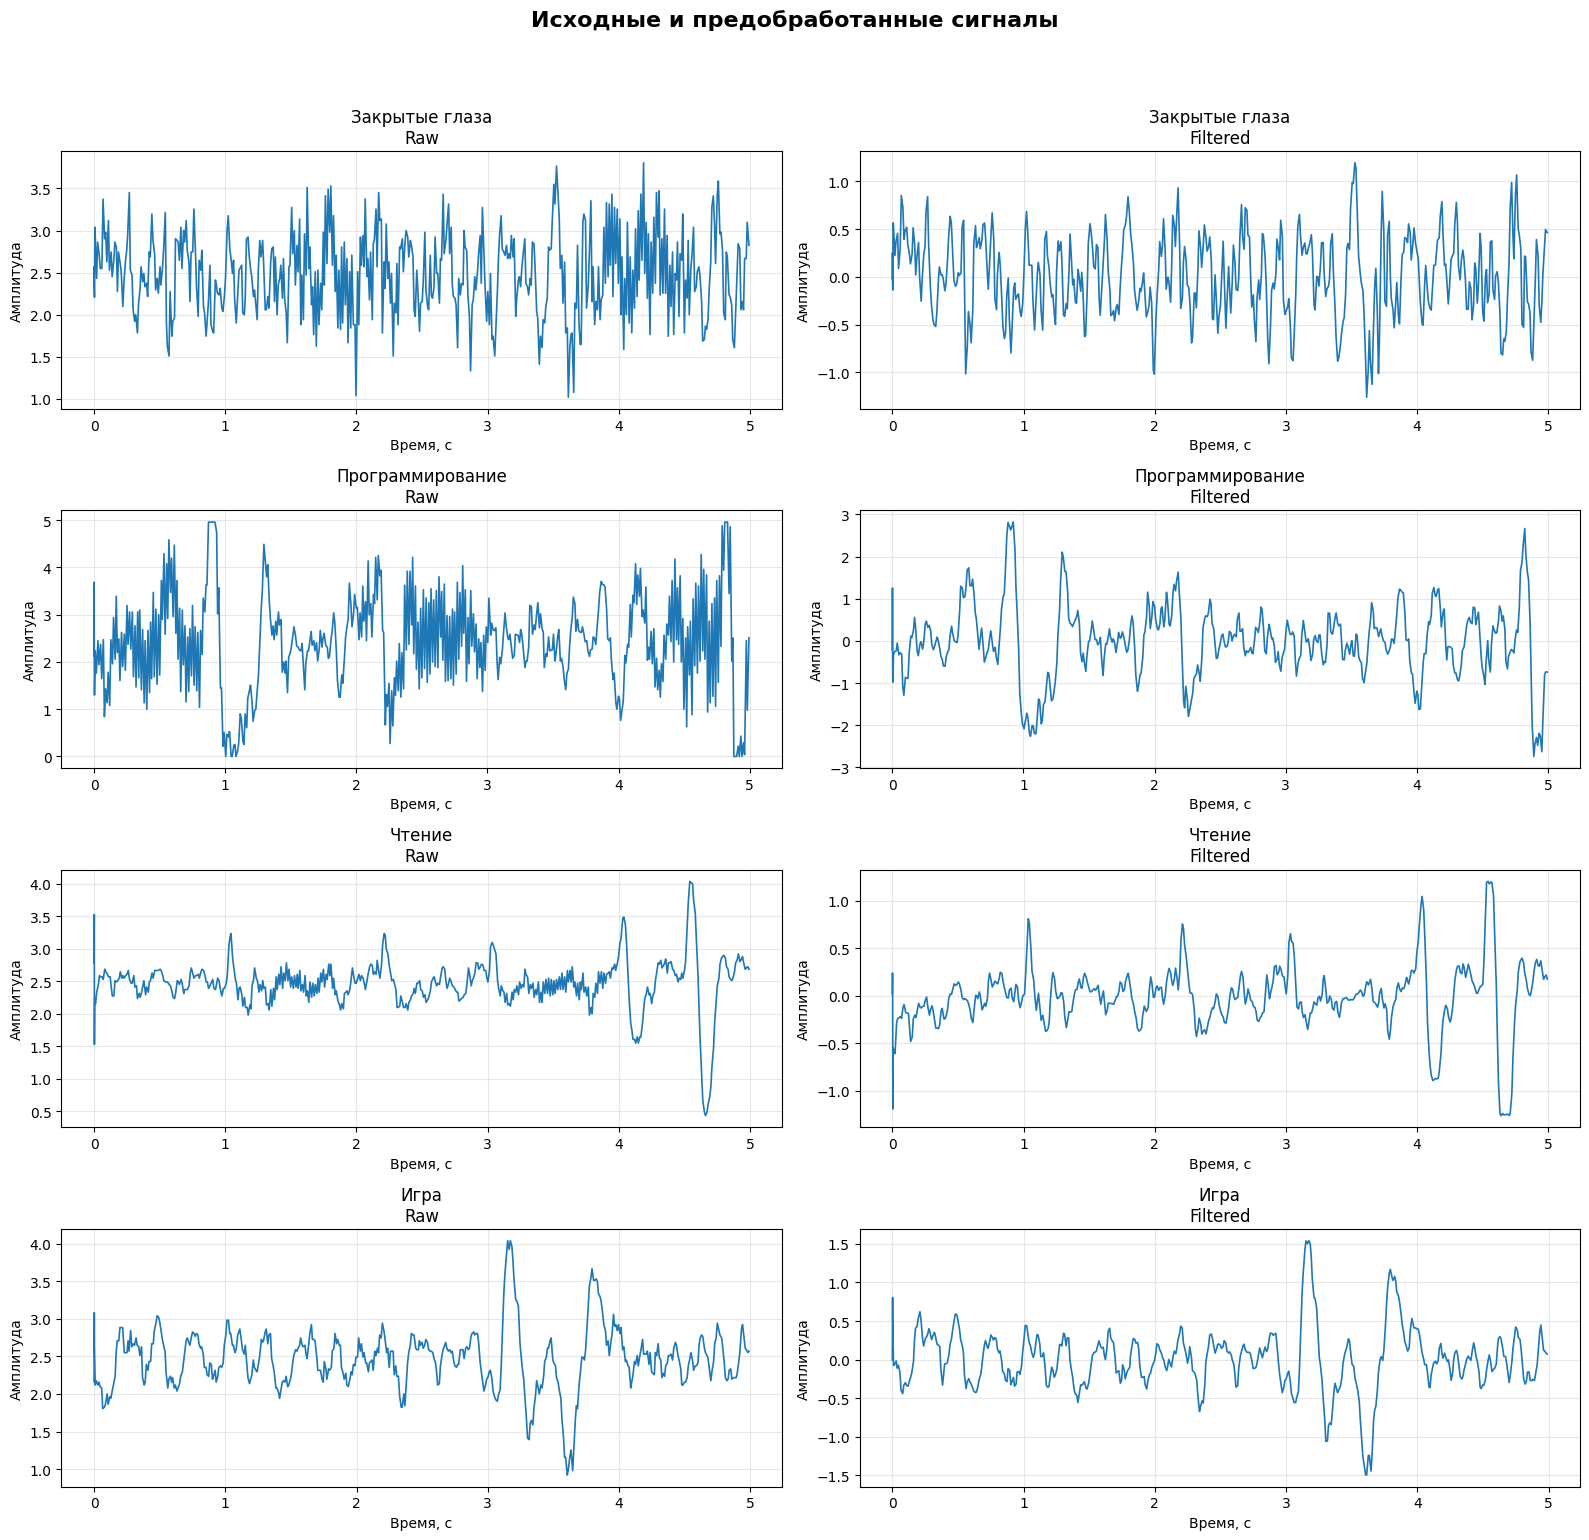

In [ ]:
# Raw vs Filtered
if proc_data:
    n = len(proc_data)
    fig, axes = plt.subplots(n, 2, figsize=(16, 4 * n))
    if n == 1:
        axes = np.array([axes])

    fig.suptitle("Исходные и предобработанные сигналы", fontsize=16, fontweight="bold")

    for i, (cond, d) in enumerate(proc_data.items()):
        t = d["time"]
        raw = d["signal_raw"]
        flt = d["signal_filtered"]

        mask = t <= 5

        axes[i, 0].plot(t[mask], raw[mask], linewidth=1.2)
        axes[i, 0].set_title(f"{cond}\nRaw")
        axes[i, 0].set_xlabel("Время, с")
        axes[i, 0].set_ylabel("Амплитуда")
        axes[i, 0].grid(True, alpha=0.3)

        axes[i, 1].plot(t[mask], flt[mask], linewidth=1.2)
        axes[i, 1].set_title(f"{cond}\nFiltered")
        axes[i, 1].set_xlabel("Время, с")
        axes[i, 1].set_ylabel("Амплитуда")
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()


## Расчет каппы


In [ ]:
# Расчет каппы
kappa_results: dict[str, dict] = {}

for cond, d in proc_data.items():
    res = kappa_analysis(d["signal_filtered"], d["fs"])

    kappa_results[cond] = {
        **d,
        **res,
        "duration": float(d["time"][-1]) if len(d["time"]) else np.nan
    }

    print(f"{cond}: rel={res['relative_power']:.4f}, kappa_abs={res['kappa_power']:.6f}")


Закрытые глаза: rel=0.2421, kappa_abs=0.029512
Программирование: rel=0.2919, kappa_abs=0.021683
Чтение: rel=0.3107, kappa_abs=0.006120
Игра: rel=0.3747, kappa_abs=0.006573


## Сравнительные графики

Рисуем:
1) столбики по относительной каппе,
2) PSD для всех условий на одном графике,
3) каппа-сигнал


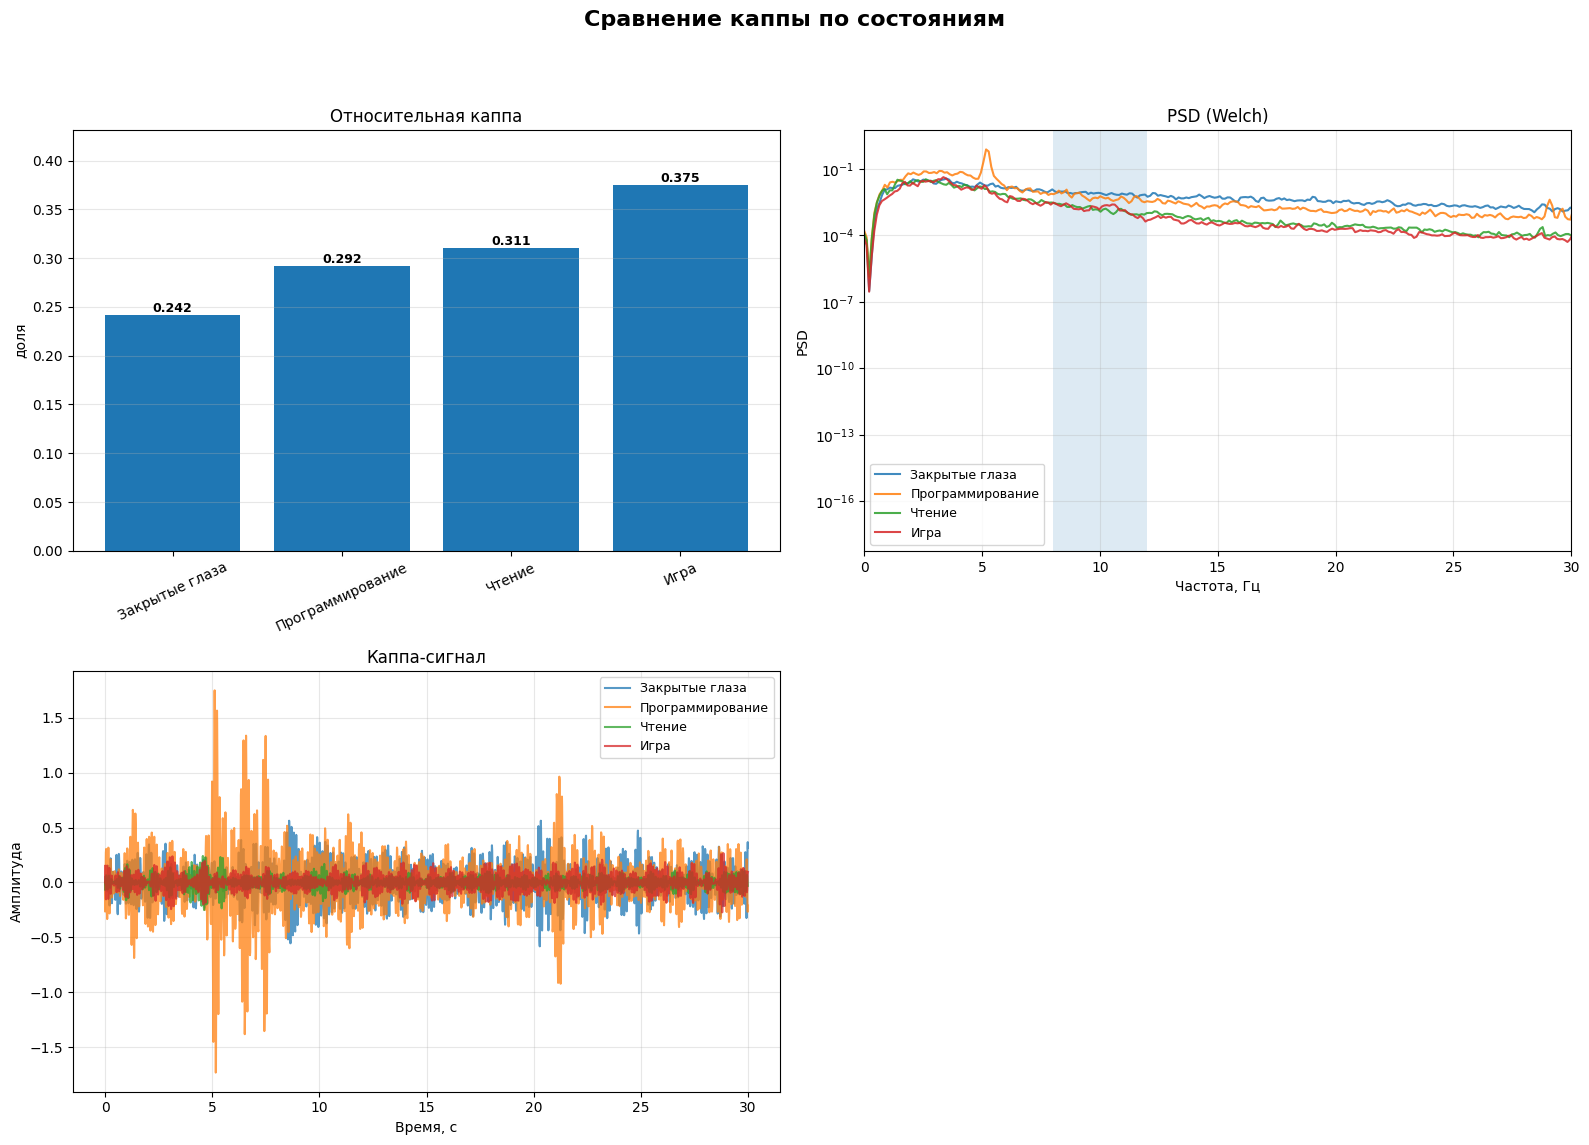

In [ ]:
# Сравнение условий
if kappa_results:
    conds = list(kappa_results.keys())
    rels = [kappa_results[c]["relative_power"] for c in conds]
    abss = [kappa_results[c]["kappa_power"] for c in conds]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Сравнение каппы по состояниям", fontsize=16, fontweight="bold")

    # относительная мощность
    bars = ax1.bar(conds, rels)
    ax1.set_title("Относительная каппа")
    ax1.set_ylabel("доля")
    ax1.tick_params(axis="x", rotation=25)
    ax1.grid(True, axis="y", alpha=0.3)
    if rels:
        ax1.set_ylim(0, max(rels) * 1.15)
    for b, v in zip(bars, rels):
        ax1.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

    # PSD overlay
    ax2.set_title("PSD (Welch)")
    ax2.set_xlabel("Частота, Гц")
    ax2.set_ylabel("PSD")
    for c in conds:
        ax2.plot(kappa_results[c]["freqs"], kappa_results[c]["psd"], label=c, alpha=0.85, linewidth=1.5)
    ax2.set_yscale("log")
    ax2.grid(True, which="both", alpha=0.3)
    ax2.axvspan(KAPPA_BAND[0], KAPPA_BAND[1], alpha=0.15)
    ax2.set_xlim(0, 30)
    ax2.legend(fontsize=9)

    # каппа-сигнал
    ax3.set_title("Каппа-сигнал")
    ax3.set_xlabel("Время, с")
    ax3.set_ylabel("Амплитуда")
    for c in conds:
        t = kappa_results[c]["time"]
        m = t <= 30
        if np.any(m):
            ax3.plot(t[m], kappa_results[c]["kappa_signal"][m], label=c, alpha=0.75)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)

    ax4.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()


## Детальные графики по каждому состоянию


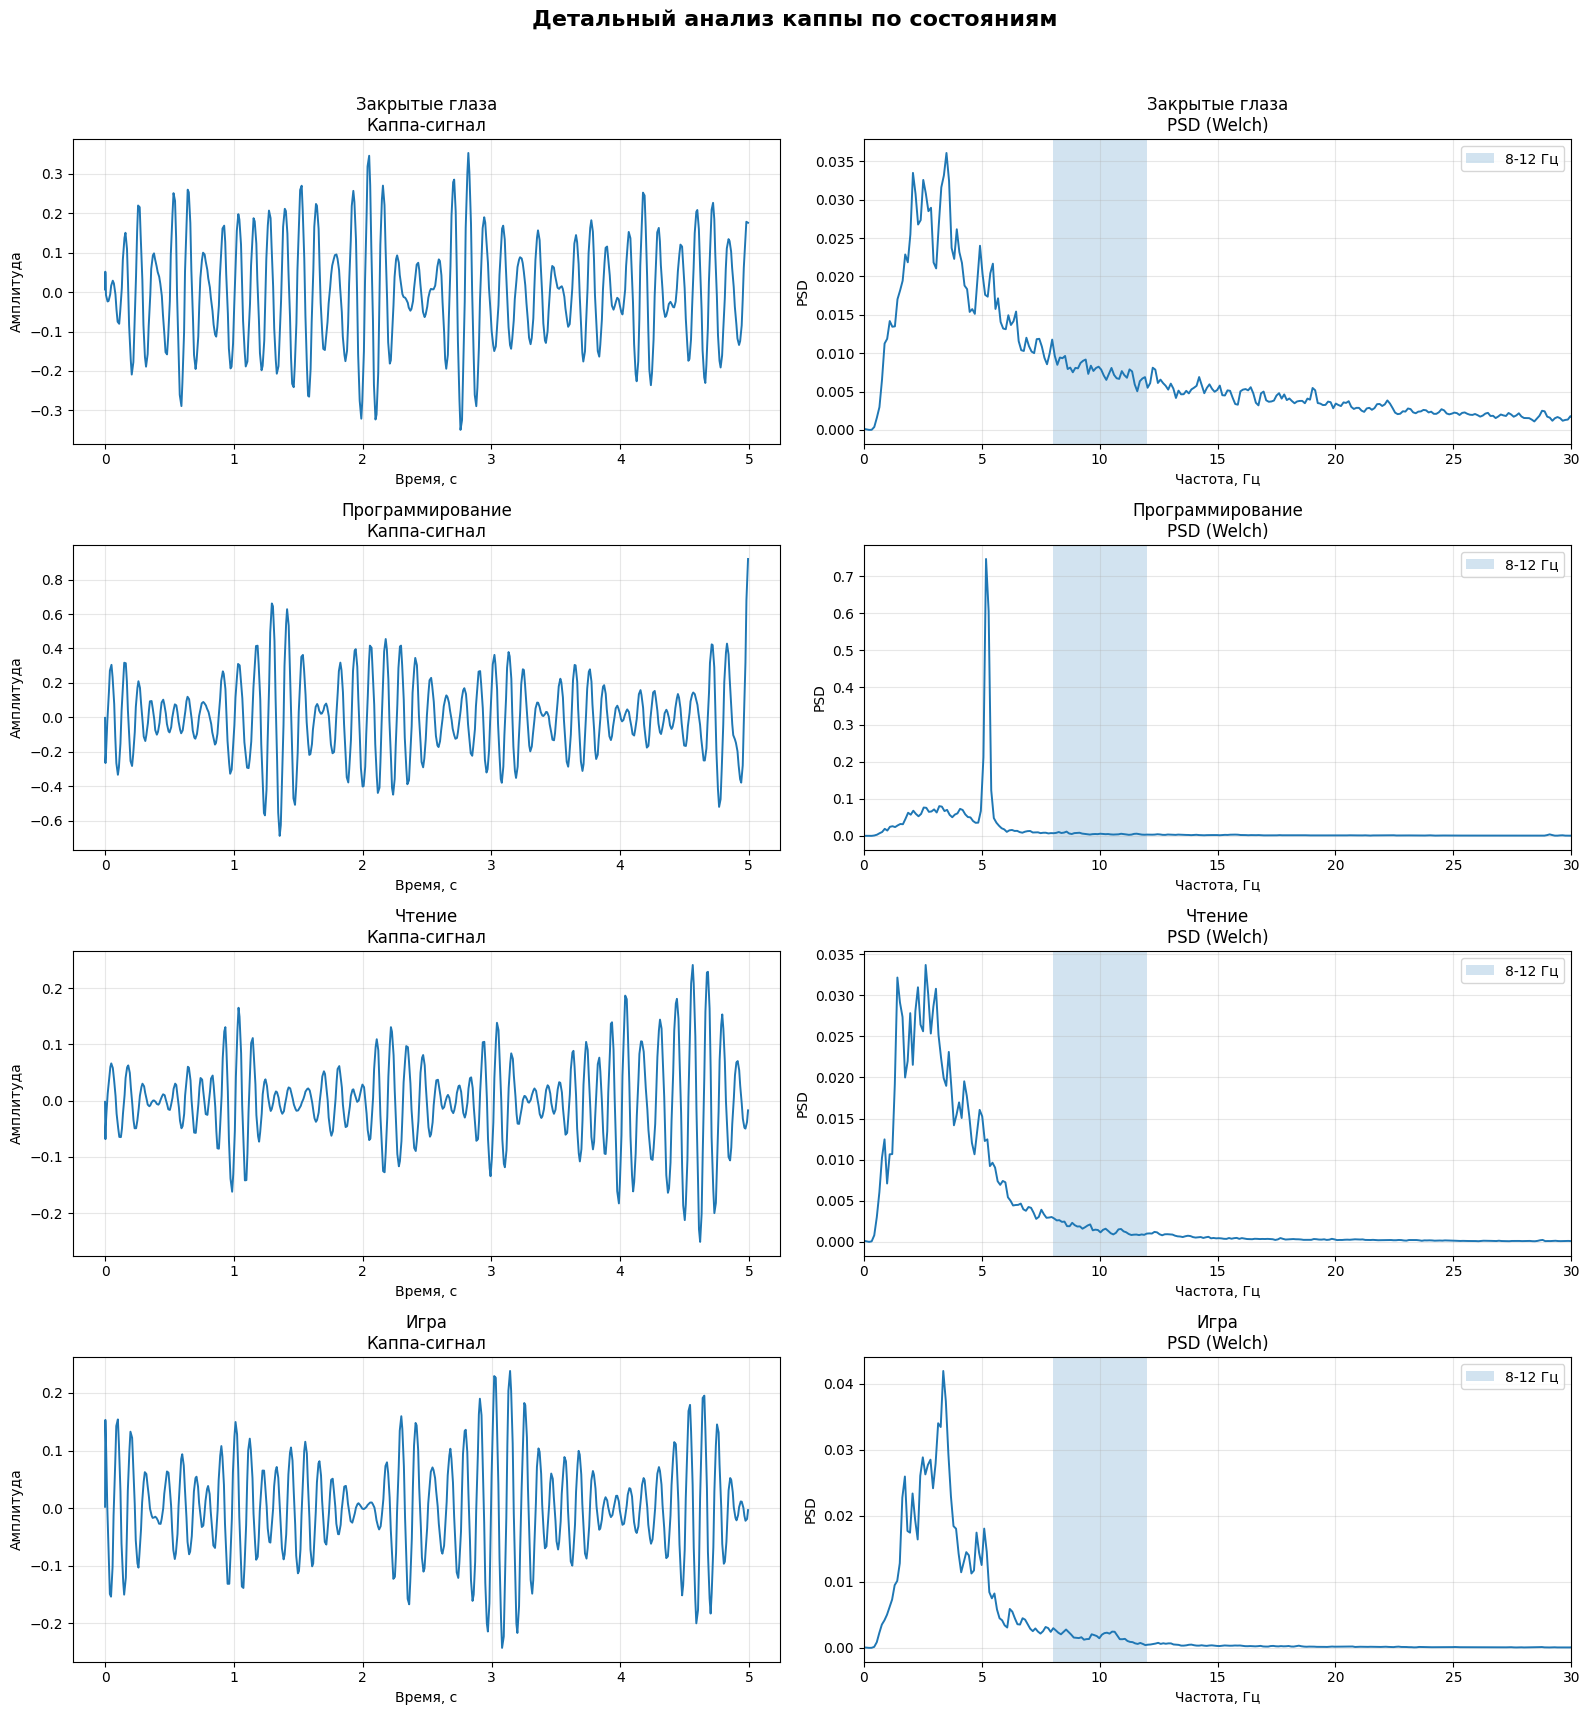

In [ ]:
# Детальный просмотр по состояниям
if kappa_results:
    n = len(kappa_results)
    fig, axes = plt.subplots(n, 2, figsize=(16, 4.5 * n))
    if n == 1:
        axes = np.array([axes])

    fig.suptitle("Детальный анализ каппы по состояниям", fontsize=16, fontweight="bold")

    for i, (cond, d) in enumerate(kappa_results.items()):
        t = d["time"]
        m5 = t <= 5

        axes[i, 0].plot(t[m5], d["kappa_signal"][m5], linewidth=1.4)
        axes[i, 0].set_title(f"{cond}\nКаппа-сигнал")
        axes[i, 0].set_xlabel("Время, с")
        axes[i, 0].set_ylabel("Амплитуда")
        axes[i, 0].grid(True, alpha=0.3)

        axes[i, 1].plot(d["freqs"], d["psd"], linewidth=1.4)
        axes[i, 1].axvspan(KAPPA_BAND[0], KAPPA_BAND[1], alpha=0.2, label="8-12 Гц")
        axes[i, 1].set_title(f"{cond}\nPSD (Welch)")
        axes[i, 1].set_xlabel("Частота, Гц")
        axes[i, 1].set_ylabel("PSD")
        axes[i, 1].set_xlim(0, 30)
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


## Итоговая таблица и вывод


In [ ]:
# Таблица и вывод
if kappa_results:
    table = []
    for cond, d in kappa_results.items():
        table.append({
            "Состояние": cond,
            "Отн. каппа (доля)": d["relative_power"],
            "Общая мощность": d["total_power"],
        })

    df = pd.DataFrame(table).sort_values("Отн. каппа (доля)", ascending=False).reset_index(drop=True)

    display(
        df.style.format({
            "Отн. каппа (доля)": "{:.4f}",
            "Общая мощность": "{:.4f}",
        }).set_caption("Результаты анализа каппы (8-12 Гц)")
    )

    best = df.iloc[0]
    worst = df.iloc[-1]

    print(f"Наибольшая каппа: '{best['Состояние']}' ({best['Отн. каппа (доля)']:.4f})")
    print(f"Наименьшая каппа: '{worst['Состояние']}' ({worst['Отн. каппа (доля)']:.4f})")


,Состояние,Отн. каппа (доля),Общая мощность
0,Игра,0.3747,0.0175
1,Чтение,0.3107,0.0197
2,Программирование,0.2919,0.0743
3,Закрытые глаза,0.2421,0.1219


Наибольшая каппа: 'Игра' (0.3747)
Наименьшая каппа: 'Закрытые глаза' (0.2421)


## Выводы

По доле 8-12 Гц в общем диапазоне:

1) Игра - 0.3747 (максимум)  
2) Чтение - 0.3107  
3) Программирование - 0.2919  
4) Закрытые глаза - 0.2421 (минимум)

Каппа-ритм наиболее выражен при задачах, требующих интенсивного визуально-пространственного мышления и концентрации внимания.

Результат соответствует этой идее:
- "Игра" и "чтение" - интенсивная визуальная обработка и внимание,
- "Закрытые глаза" - меньше визуальной нагрузки и меньше "рабочего режима"
